This notebook trains and evaluates emotion classifiers for pet faces using:
- A custom ResNet trained from scratch
- Transfer learning with ImageNet pretrained weights
Metrics reported: accuracy, macro-precision/recall/F1, and confusion matrix.

## Imports & Setup
Load libraries, dataloaders, and helper plotting/metrics functions.

In [28]:
import os
import importlib
import torch
import torch.nn as nn
from torchvision import models
import cv2
import numpy as np
import matplotlib.pyplot as plt
from data_loader import get_dataloaders, DataLoaderConfig

import utils
importlib.reload(utils)
from utils import plot_loss_and_accuracy, report_classification_metrics

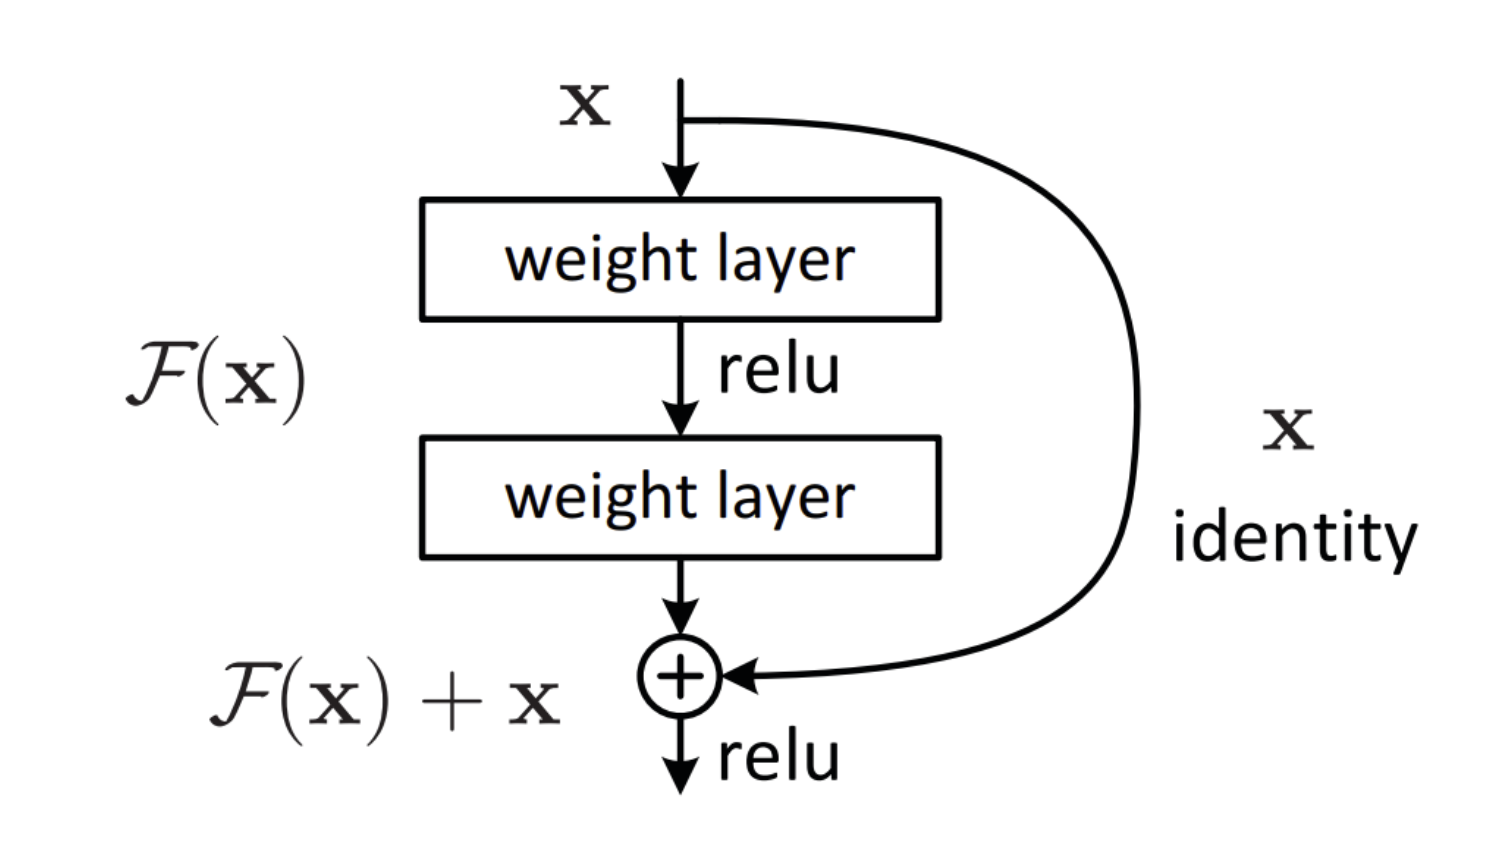

## Model (From Scratch)
Define the building blocks and the custom ResNet architecture implemented from scratch.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, inplanes: int, 
                planes: int, 
                stride: int = 1, ):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1,bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        
        self.residual = nn.Sequential()
        if stride != 1 or inplanes != planes:
            self.residual = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        identity = self.residual(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out += identity

        out = self.relu(out)

        return out

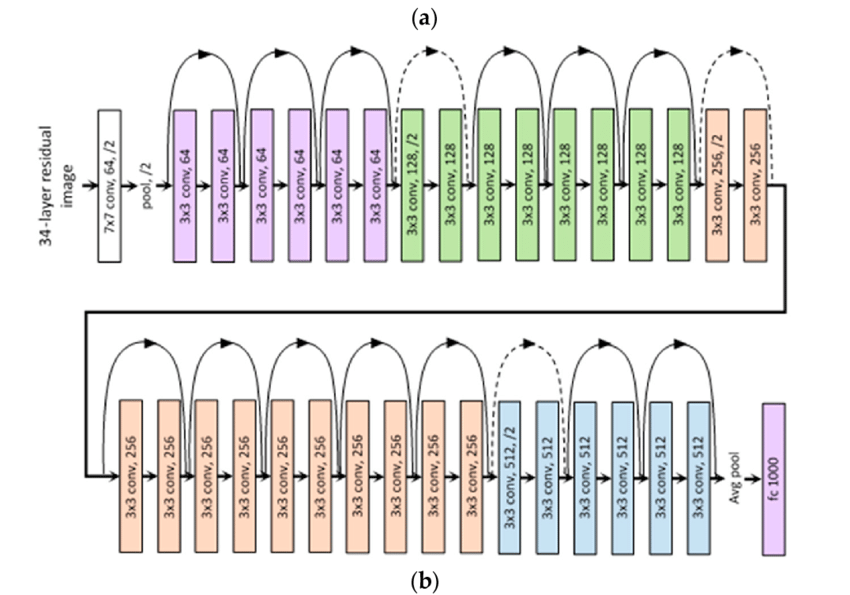

In [3]:
class ResNet(nn.Module):
    def __init__(self, 
                block: ResidualBlock, 
                num_of_blocks: list, # num of blocks in each layer
                num_classes: int):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inplanes = 64
        # layer1 64
        self.layer_1 = self._make_layer(block, 64, num_of_blocks[0], stride=1)
        # layer2 128
        self.layer_2 = self._make_layer(block, 128, num_of_blocks[1], stride=2)
        # layer3 256
        self.layer_3 = self._make_layer(block, 256, num_of_blocks[2], stride=2)
        # layer4 512
        self.layer_4 = self._make_layer(block, 512, num_of_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # initialize weights
        self._initialize_weights()


    def _make_layer(self, block: ResidualBlock, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inplanes, planes, stride))
            self.inplanes = planes 
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        # Initialize weights using Kaiming He initialization for convolutional layers and normal distribution for linear layers.
        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)
        x = self.layer_4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

## Training & Validation Loops
Define per-epoch training and evaluation functions (loss + accuracy).

In [4]:
def train_one_epoch(model, train_loader, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [5]:
@torch.no_grad()
def evaluate_one_epoch(model, test_loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            criterion = nn.CrossEntropyLoss()
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [6]:
loader, classes = get_dataloaders(DataLoaderConfig())
train_loader = loader['train']
val_loader = loader['valid']
test_loader = loader['test']

## Train From Scratch
Train the custom ResNet from scratch, cache the best checkpoint by validation loss, then plot learning curves.

In [29]:
# train the model (cache best checkpoint by validation loss)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet(ResidualBlock, [2, 2, 2, 2], num_classes=len(classes)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4) # Adam optimizer with weight decay for regularization
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( # Reduce learning rate when a metric has stopped improving.
    optimizer,
    mode='min', # mode='min' means we want to minimize the validation loss
    patience=3, # number of epochs with no improvement after which learning rate will be reduced
    factor=0.5) # factor by which the learning rate will be reduced. new_lr = lr * factor

best_ckpt_path = os.path.join("models", "best_resnet_2_2_2_2.pth")
os.makedirs("models", exist_ok=True)
best_val_loss = float("inf")

num_epochs = 50
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate_one_epoch(model, val_loader, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # cache best model
    if val_loss < best_val_loss:
        print(f"\tNew best model found at epoch {epoch+1} with val_loss={val_loss:.4f}, val_acc={val_acc:.2f}")
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "classes": classes,
            },
            best_ckpt_path,
        )

    scheduler.step(val_loss)  # Update learning rate based on validation loss

    print(f'Epoch {epoch+1}/{num_epochs}, Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

print(f"Best checkpoint saved to: {best_ckpt_path} (val_loss={best_val_loss:.4f})")

	New best model found at epoch 1 with val_loss=1.2955, val_acc=33.33
Epoch 1/50, Learning Rate: 0.001000, Train Loss: 1.4513, Train Acc: 25.40%, Val Loss: 1.2955, Val Acc: 33.33%
Epoch 2/50, Learning Rate: 0.001000, Train Loss: 1.4072, Train Acc: 28.90%, Val Loss: 2.0594, Val Acc: 22.22%
	New best model found at epoch 3 with val_loss=1.2459, val_acc=44.44
Epoch 3/50, Learning Rate: 0.001000, Train Loss: 1.4040, Train Acc: 29.00%, Val Loss: 1.2459, Val Acc: 44.44%
	New best model found at epoch 4 with val_loss=1.2040, val_acc=36.11
Epoch 4/50, Learning Rate: 0.001000, Train Loss: 1.3724, Train Acc: 29.30%, Val Loss: 1.2040, Val Acc: 36.11%
Epoch 5/50, Learning Rate: 0.001000, Train Loss: 1.3677, Train Acc: 33.00%, Val Loss: 1.4391, Val Acc: 25.00%
Epoch 6/50, Learning Rate: 0.001000, Train Loss: 1.3663, Train Acc: 32.00%, Val Loss: 1.6102, Val Acc: 30.56%
Epoch 7/50, Learning Rate: 0.001000, Train Loss: 1.3555, Train Acc: 33.00%, Val Loss: 1.3923, Val Acc: 25.00%
Epoch 8/50, Learning Ra

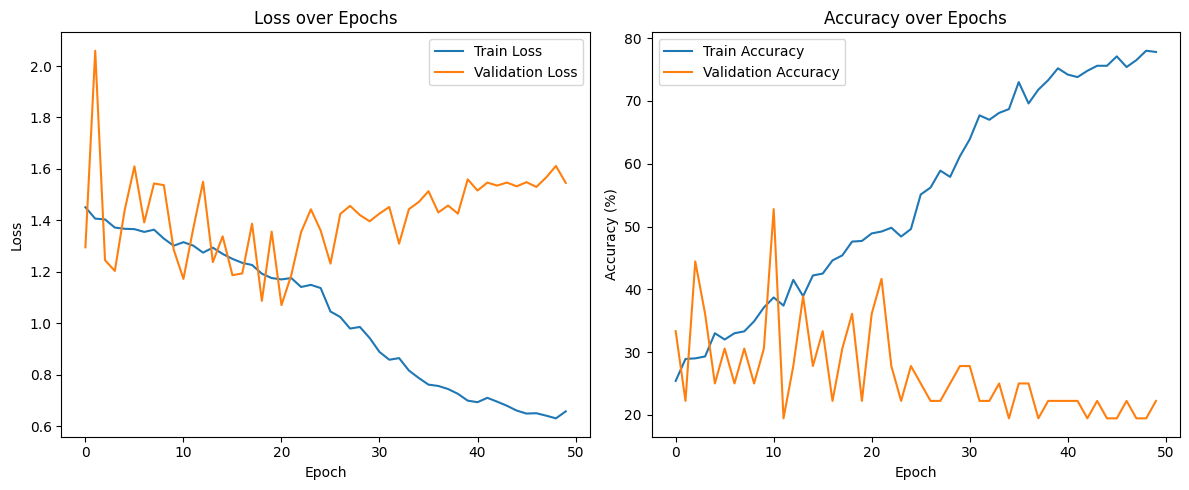

In [31]:
plot_loss_and_accuracy(train_losses, val_losses, train_accuracies, val_accuracies)

## Test Set Evaluation & Report
Load the best cached checkpoint (if available), evaluate on the test set, and report accuracy, macro Precision/Recall/F1, and the confusion matrix.

Loaded best checkpoint: models\best_resnet_2_2_2_2.pth (val_loss=1.071315884590149)
Test Loss: 1.3649, Test Acc: 39.47%
ResNet - Accuracy: 39.47%
ResNet - Macro Precision/Recall/F1: 0.3972 / 0.3735 / 0.3658
ResNet - Confusion Matrix (rows=true, cols=pred):
[[6 1 2 1]
 [4 1 0 1]
 [4 2 3 2]
 [4 1 1 5]]


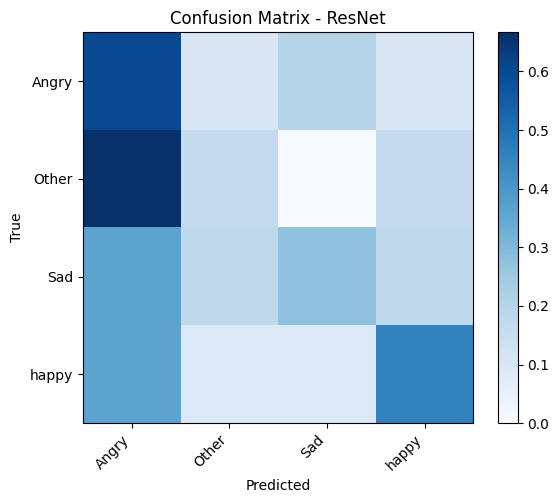

In [33]:
# inference on test set (load best cached checkpoint if available)
if 'best_ckpt_path' in globals() and os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=device)
    state = ckpt.get("model_state_dict", ckpt)
    model.load_state_dict(state)
    print(f"Loaded best checkpoint: {best_ckpt_path} (val_loss={ckpt.get('val_loss', 'n/a')})")
else:
    print("No cached checkpoint found; evaluating current model weights.")

test_loss, test_acc = evaluate_one_epoch(model, test_loader, device)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
metrics = report_classification_metrics(
    model,
    test_loader,
    device,
    class_names=classes,
    title="ResNet",
    plot_confusion_matrix=True,
    normalize_confusion_matrix="true",  # optional: None/'true'/'pred'/'all'
)

## Transfer Learning (ImageNet Weights)
Fine-tune an ImageNet-pretrained model (e.g., ResNet18) on the same dataset, cache the best checkpoint, then evaluate on the test set with the same metrics.

	New best TL model @ epoch 1: val_loss=1.0373, val_acc=36.11%
[TL] Epoch 1/10 lr=1.00e-03 train_loss=1.4001 train_acc=30.00% val_loss=1.0373 val_acc=36.11%
[TL] Epoch 2/10 lr=1.00e-03 train_loss=1.1845 train_acc=46.70% val_loss=1.1089 val_acc=36.11%
[TL] Epoch 3/10 lr=1.00e-03 train_loss=1.1446 train_acc=51.90% val_loss=1.0720 val_acc=41.67%
	New best TL model @ epoch 4: val_loss=0.9172, val_acc=44.44%
[TL] Epoch 4/10 lr=1.00e-03 train_loss=1.0966 train_acc=54.50% val_loss=0.9172 val_acc=44.44%
[TL] Epoch 5/10 lr=1.00e-03 train_loss=1.0248 train_acc=55.90% val_loss=1.0334 val_acc=44.44%
[TL] Epoch 6/10 lr=1.00e-03 train_loss=1.0160 train_acc=58.30% val_loss=1.0285 val_acc=44.44%
[TL] Epoch 7/10 lr=5.00e-04 train_loss=0.9903 train_acc=60.90% val_loss=1.0533 val_acc=47.22%
[TL] Epoch 8/10 lr=5.00e-04 train_loss=0.9582 train_acc=61.80% val_loss=1.1062 val_acc=52.78%
[TL] Epoch 9/10 lr=5.00e-04 train_loss=0.9579 train_acc=62.60% val_loss=1.0609 val_acc=47.22%
[TL] Epoch 10/10 lr=2.50e-04 t

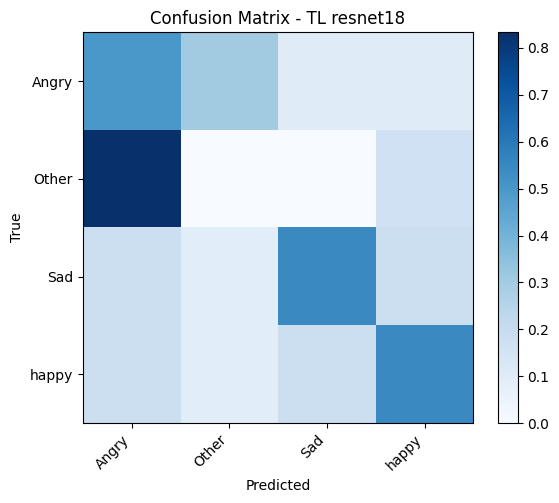

In [34]:
tl_model_name = "resnet18"  
tl_epochs = 10

tl_best_ckpt = os.path.join("models", f"best_tl_{tl_model_name}.pth")
os.makedirs("models", exist_ok=True)

# build pretrained model + replace classifier
try:
    weights = models.ResNet18_Weights.DEFAULT
    tl_model = models.resnet18(weights=weights)
except AttributeError:
    tl_model = models.resnet18(pretrained=True)
tl_model.fc = nn.Linear(tl_model.fc.in_features, len(classes))
head_params = list(tl_model.fc.parameters())

# freeze backbone
for p in tl_model.parameters():
    p.requires_grad = False
for p in head_params:
    p.requires_grad = True

tl_model = tl_model.to(device)

tl_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
tl_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tl_optimizer, mode="min", patience=2, factor=0.5
 )

# ---- train + cache best checkpoint ----
best_val = float("inf")
for epoch in range(tl_epochs):
    tr_loss, tr_acc = train_one_epoch(tl_model, train_loader, tl_optimizer, device)
    va_loss, va_acc = evaluate_one_epoch(tl_model, val_loader, device)
    tl_scheduler.step(va_loss)

    if va_loss < best_val:
        best_val = va_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": tl_model.state_dict(),
                "val_loss": va_loss,
                "val_acc": va_acc,
                "classes": classes,
            },
            tl_best_ckpt,
        )
        print(f"\tNew best TL model @ epoch {epoch+1}: val_loss={va_loss:.4f}, val_acc={va_acc:.2f}%")

    print(
        f"[TL] Epoch {epoch+1}/{tl_epochs} "
        f"lr={tl_optimizer.param_groups[0]['lr']:.2e} "
        f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% "
        f"val_loss={va_loss:.4f} val_acc={va_acc:.2f}%"
    )

print(f"Best TL checkpoint: {tl_best_ckpt} (val_loss={best_val:.4f})")

# ---- load best + evaluate on test ----
ckpt = torch.load(tl_best_ckpt, map_location=device)
tl_model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded TL checkpoint: {tl_best_ckpt} (val_loss={ckpt.get('val_loss')}, val_acc={ckpt.get('val_acc')})")

metrics_tl = report_classification_metrics(
    tl_model,
    test_loader,
    device,
    class_names=classes,
    title=f"TL {tl_model_name}",
    plot_confusion_matrix=True,
    normalize_confusion_matrix="true",
)